# UT05. Visualización de datos

[Visualization Curriculum](https://idl.uw.edu/visualization-curriculum/intro.html)

# 1.- Introducción a Altair

Altair es una librería de visualización estadística declarativa para Python. Altair ofrece una gramática de visualización potente y concisa para construir una amplia gama de gráficos estadísticos.

Los datos de Altair se estructuran en torno al DataFrame de Pandas. Alternativamente, también se puede aceptar una URL para cargar un dataset accesible a través de la red.

En este Notebook vamos a utilizar un dataset disponible en la librería `vega_datasets`, que contiene una serie de datos listos para ser utilizados.

In [3]:
%pip install vega_datasets altair

  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached narwhals-2.19.0-py3-none-any.whl.metadata (14 kB)
Using cached altair-6.0.0-py3-none-any.whl (795 kB)
Using cached narwhals-2.19.0-py3-none-any.whl (446 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [altair]━━━━ 1/2 [altair]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Importaciones
from vega_datasets import data  
import pandas as pd
import altair as alt

In [5]:
print(data.list_datasets())

['7zip', 'airports', 'annual-precip', 'anscombe', 'barley', 'birdstrikes', 'budget', 'budgets', 'burtin', 'cars', 'climate', 'co2-concentration', 'countries', 'crimea', 'disasters', 'driving', 'earthquakes', 'ffox', 'flare', 'flare-dependencies', 'flights-10k', 'flights-200k', 'flights-20k', 'flights-2k', 'flights-3m', 'flights-5k', 'flights-airport', 'gapminder', 'gapminder-health-income', 'gimp', 'github', 'graticule', 'income', 'iowa-electricity', 'iris', 'jobs', 'la-riots', 'londonBoroughs', 'londonCentroids', 'londonTubeLines', 'lookup_groups', 'lookup_people', 'miserables', 'monarchs', 'movies', 'normal-2d', 'obesity', 'ohlc', 'points', 'population', 'population_engineers_hurricanes', 'seattle-temps', 'seattle-weather', 'sf-temps', 'sp500', 'stocks', 'udistrict', 'unemployment', 'unemployment-across-industries', 'uniform-2d', 'us-10m', 'us-employment', 'us-state-capitals', 'volcano', 'weather', 'weball26', 'wheat', 'windvectors', 'world-110m', 'zipcodes']


In [6]:
df = data.cars()
df.head(3)

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA


## 1.1.- Conceptos fundamentales de Altair

### El objeto `Chart`

El componente central de Altair es `Chart`. Su función principal es recibir los datos (generalmente un DataFrame de Pandas) para iniciar la visualización. El objeto `Chart` por sí solo no genera una gráfica, sino que será necesario indicarle qué hacer con esos datos.

### Marks (marcas)

Las **marcas** definen la forma geométrica que representará los datos en el gráfico. Se acceden mediante los métodos `Chart.mark_*()`. Por ejemplo, `.mark_point()` crea puntos o `.mark_bar()` crea barras. Si usamos una marca sin definir canales, Altair dibujará todos los puntos uno sobre otro.

In [7]:
alt.Chart(df).mark_point()

alt.Chart(...)

## Encodings (codificaciones

Los canales de codificación **vinculan las variables de tus datos con las propiedades visuales**. Se definen con el método `.encode()`. Algunos canales comunes son: `x`, `y` (posiciones), `shape` (forma)o `size` (tamaño).

Con el siguiente código le estamos diciendo que distribuya los valores de la columna `Origin` en el eje Y.

In [8]:
( alt
     .Chart(df)
     .mark_point()
     .encode(
         y='Origin'
     )
)

alt.Chart(...)

Como puedes ver, únicamente pone un punto en cada posición, porque solo le estamos dando un eje. Vamos a decirle que nos sitúe ahora en el **eje X** los valores de la columna `Miles_per_Gallon`.

In [9]:
( alt
     .Chart(df)
     .mark_point()
     .encode(
         y='Origin',
         x='Miles_per_Gallon'
     )
)

alt.Chart(...)

In [10]:
( alt
     .Chart(df)
     .mark_point()
     .encode(
         y='Horsepower',
         x='Miles_per_Gallon'
     )
)

alt.Chart(...)

Alternativamente al parámetro `x` podemos usar `alt.X()` para establecer la codificación. Esto, como veremos algo más adelante, permitirá personalizar más la representación en cada uno de los ejes.

Otro aspecto a tener en cuenta es el **tipo de datos**. Cuando estamos cargando datos de un DataFrame de Pandas tomará el que tiene 

In [11]:
( alt
     .Chart(df)
     .mark_point()
     .encode(
         alt.Y('Horsepower'),
         alt.X('Miles_per_Gallon')
     )
)

alt.Chart(...)

# 2.- Tipos de datos, marcas y canales de codificación visual

Una visualización representa datos utilizando una colección de **marcas gráficas** (barras, líneas, puntos, ...). Los atributos de la marca (posición, forma, color o tamaño) sirven como canal a través del cual codificamos los valores de los datos.

## 2.1.- Global Development Data

Vamos a utilizar un dataset que contiene datos sobre la salud global y la población de un gran número de países en el periodo comprendido entre 1955 y 2005. Estos datos fueron recopilados por la [Gapminder Foundation](https://www.gapminder.org/) y fueron el mostrados en la popular [charla TED de Hans Rosling](https://www.youtube.com/watch?v=hVimVzgtD6w)

In [12]:
from vega_datasets import data as vega_data
df = vega_data.gapminder()

In [13]:
df.shape

(693, 6)

In [14]:
df.head(5)

,year,country,cluster,pop,life_expect,fertility
0,1955,Afghanistan,0,8891209,30.332,7.7
1,1960,Afghanistan,0,9829450,31.997,7.7
2,1965,Afghanistan,0,10997885,34.020,7.7
3,1970,Afghanistan,0,12430623,36.088,7.7
4,1975,Afghanistan,0,14132019,38.438,7.7


Vamos a quedarnos solo con un subconjunto de los datos

In [15]:
df2000 = df.loc[df['year'] == 2000]

## 2.2.- Tipos de datos

En Altair hay diferentes tipos de datos que determinarán los tipos de comparaciones que podemos realizar y, por tanto, guiar nuestras decisiones de diseño en la visualización. Estos tipos son:

- **Nominal (N)**: son categorías puras sin orden jerárquico que solo permiten comparaciones de igualdad. Se representan mejor con **formas o distintos colores (matices)**, evitando siempre el uso del tamaño, ya que este sugeriría erróneamente que una categoría es más que otra.
- **Ordinal (O)**: representan valores con un orden intrínseco o ranking (A<B), como niveles de intensidad. Para que la visualización sea efectiva, se debe usar la **posición, el tamaño o el brillo del color**, descartando el matiz cromático porque no transmite una sensación natural de secuencia.
- **Cuantitativo (Q)**: son valores para medir distancias o proporciones exactas. Se dividen en datos de **intervalo** (distancia relativa) o de **razón** (con cero absoluto), siendo estos últimos los que requieren obligatoriamente un eje que parta de cero para no engañar al ojo con las proporciones visuales.
- **Temporal (T)**: es una variante especializada de los datos cuantitativos que incluye la lógica del calendario, como meses o días de la semana. Su ventaja principal es que permite manejar **fechas y horas** de forma inteligente, reconociendo intervalos temporales complejos en lugar de tratarlos como simples números aislados.

## 2.3.- Canales de codificación

En el núcleo de Altair se encuentra el uso de **codificaciones** (encodings) que vinculan campos de datos (con un tipo de dato determinado) con los canales de codificación disponibles de un tipo de marca elegido. En este cuaderno examinaremos los siguientes canales de codificación:

- `x`: Posición horizontal (eje x) de la marca.
- `y`: Posición vertical (eje y) de la marca.
- `size`: Tamaño de la marca. Puede corresponder al área o a la longitud, dependiendo del tipo de marca.
- `color`: Color de la marca, especificado como un color CSS válido.
- `opacity`: Opacidad de la marca, con un rango que va desde 0 (completamente transparente) hasta 1 (completamente opaco).
- `shape`: Forma del símbolo de trazado para las marcas de puntos.
- `tooltip`: Texto de la descripción emergente que se muestra al pasar el ratón sobre la marca.
- `order`: Orden de la marca; determina el orden de los puntos en líneas o áreas y el orden de dibujo.
- `column`: Facetar (dividir) los datos en subgráficos alineados horizontalmente.
- `row`: Facetar (dividir) los datos en subgráficos alineados verticalmente.

Para obtener una lista completa de los canales disponibles, consulta la documentación de codificación de Altair.

### 2.3.1.- X

El canal de codificación `x` establece una marca en posición horizontal

In [16]:
( alt.Chart(df2000)
     .mark_point()
     .encode(
        alt.X('fertility:Q')
    )
)

alt.Chart(...)

### 2.3.2.- Y

El canal de codificación `y` establece una marca en posición vertical. En el siguiente código se añade el campo `cluster` utilizando el tipo de datos ordinal (`O`). Observa que el resultado es un eje discreto que incluye una banda con tamaño definido y un incremento predeterminado para cada uno de sus valores únicos.

In [17]:
( alt.Chart(df2000)
     .mark_point()
     .encode(
        alt.X('fertility:Q'),
        alt.Y('cluster:O')
    )
)

alt.Chart(...)

Si, por el contrario, añadimos el campo `life_expect` como una variable cuantitativa (`Q`), el resultado es un gráfico de dispersión con escalas lineales para ambos ejes.

In [18]:
( alt.Chart(df2000)
     .mark_point()
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q')
    )
)

alt.Chart(...)

Por defecto, los ejes de escalas cuantitativas incluyen el cero para asegurar una línea de base adecuada al comparar datos. No obstante, en ciertos casos, puede ser deseable omitirla para centrarnos en comparaciones de intervalos. Para ello hay que configurarlo utilizando el atributo **`scale`** de la codificación.

La función principal del parámetro `scale` es **mapear los valores de los datos a propiedades visuales**. En este caso lo usamos para definir el rango de visualización, pero ya veremos que tiene muchas más utilidades.

In [19]:
( alt.Chart(df2000)
     .mark_point()
     .encode(
        alt.X('fertility:Q', scale=alt.Scale(zero=False)),
        alt.Y('life_expect:Q', scale=alt.Scale(zero=False))
    )
)

alt.Chart(...)

### 2.3.3.- Tamaño

El canal de codificación `Size` establece el tamaño o extensión de una marca. El significado de este canal puede cambiar en función del tipo de marca, por ejemplo, en el caso de marcas de puntos indica el área en píxeles del símbolo de representación.

En el siguiente ejemplo codificamos la población en el canal **size**. Como consecuencia, el gráfico ahora incluye una leyenda que permite interpretar los valores asignados al tamaño.

In [20]:
( alt.Chart(df2000)
     .mark_point()
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q', scale=alt.Scale(zero=False)),
        alt.Size('pop:Q')
    )
)

alt.Chart(...)

Si no estamos satisfechos con los tamaños establecidos por defecto, podemos utilizar el atributo `scale` mediante una lista que indique los tamaños mínimo y máximo. En el siguiente ejemplo, actualizamos al codificación del tamaño para que abarque desde los 0 píxeles (para los valores equivalentes a 0) hasta los 1000 píxeles (para el valor máximo dentro del dominio de la escala).

In [21]:
( alt.Chart(df2000)
     .mark_point()
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q', scale=alt.Scale(zero=False)),
        alt.Size('pop:Q', scale=alt.Scale(range=[0,1000]))
    )
)

alt.Chart(...)

### 2.3.4.- Color y opacidad

El canal `color` codifica el color de la marca. El estilo de esta codificación depende del tipo de datos:
- Los **datos nominales** utilizarán un esquema de color cualitativo con múltiples matices
- Los **datos ordinales y cuantitativos** emplearán gradientes de color ordenados perceptualmente.

In [22]:
( alt.Chart(df2000)
     .mark_point()
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q', scale=alt.Scale(zero=False)),
        alt.Size('pop:Q', scale=alt.Scale(range=[0,1000])),
        alt.Color('cluster:N')
    )
)

alt.Chart(...)

Si preferimos figuras rellenas podemos utilizar el parámetro `filled=True`

In [23]:
( alt.Chart(df2000)
     .mark_point(filled=True)
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q'),
        alt.Size('pop:Q', scale=alt.Scale(range=[0,1000])),
        alt.Color('cluster:N')
    )
)

alt.Chart(...)

Por defecto, Altair aplica un poco de **transparencia** para contrarrestar la superposición de los puntos, pero podemos modificarla utilizando un **canal de codificación dedicado** `OpacityValue`.

In [24]:
( alt.Chart(df2000)
     .mark_point(filled=True)
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q'),
        alt.Size('pop:Q', scale=alt.Scale(range=[0,1000])),
        alt.Color('cluster:N'),
        alt.OpacityValue(0.5)
    )
)

alt.Chart(...)

### 2.3.5.- Forma

El canal de codificación `Shape` establece la **forma geométrica** utilizada por las marcas de puntos. A diferencia de otros canales que hemos visto hasta ahora, el canal de forma no puede utilizarse con otros tipos de marcas y **solo debe utilizarse con datos nominales**.

En el siguiente ejemplo, vamos a codificar el campo `cluster` utilizando tanto la forma como el color. El uso de múltiples canales para representar el mismo campo de datos subyacente se conoce como **codificación redundante**

In [25]:
( alt.Chart(df2000)
     .mark_point(filled=True)
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q', scale=alt.Scale(zero=False)),
        alt.Size('pop:Q', scale=alt.Scale(range=[0,1000])),
        alt.Color('cluster:N'),
        alt.OpacityValue(0.5),
        alt.Shape('cluster:N')
    )
)

alt.Chart(...)

### 2.3.6.- Descripciones emergentes (tooltips) y ordenación

El canal de codificación `Tooltip` determina el **texto de la descripción** que se muestra cuando el usuario desplaza el cursor del ratón sobre una marca. Vamos a añadir una codificación de *tooltip* para el campo `country`

In [26]:
( alt.Chart(df2000)
     .mark_point(filled=True)
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q'),
        alt.Size('pop:Q', scale=alt.Scale(range=[0,1000])),
        alt.Color('cluster:N'),
        alt.OpacityValue(0.5),
        alt.Tooltip('country')
    )
)

alt.Chart(...)

Si observas el resultado anterior, verás que hay un problema con los **puntos superpuestos**. Por ejemplo, detrás de la India hay un punto cuyo país no podemos conocer por encontrarse detrás. Esto se puede solucionar con el canal de codificación `Order`, que determina el orden de los puntos y, por tanto, el orden en que se dibujan.

Observa que indicamos que orden según el campo `pop` de forma descendente, de forma que dibujará primero los puntos más grandes

In [44]:
( alt.Chart(df2000)
     .mark_point(filled=True)
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q', scale=alt.Scale(zero=False)),
        alt.Size('pop:Q', scale=alt.Scale(range=[0,1000])),
        alt.Color('cluster:N'),
        alt.OpacityValue(0.5),
        alt.Tooltip('country:N'),
        alt.Order('pop:Q', sort='descending')
    )
)

alt.Chart(...)

También podemos añadir **varios *tooltips*** para mostrar diferentes valores.

In [45]:
( alt.Chart(df2000)
     .mark_point(filled=True)
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q'),
        alt.Size('pop:Q', scale=alt.Scale(range=[0,1000])),
        alt.Color('cluster:N'),
        alt.OpacityValue(0.5),
        alt.Order('pop:Q', sort='descending'),
        tooltip = [
            alt.Tooltip('country:N'),
            alt.Tooltip('fertility:Q'),
            alt.Tooltip('life_expect:Q')
        ]   
    )
)

alt.Chart(...)

### 2.3.7.- Facetas de columna y fila

La posición espacial es uno de los canales más potentes y flexibles para la codificación visual, pero solo tenemos dos canales (`x` e `y`). Un posibilidad consiste en crear un gráfico de enrejado, el cual se compone de **subgráficos** que muestran un subconjunto de los datos. Los canales de codificación `Column` y `Row` generan un **conjunto de subgráficos horizontales (columnas) y verticales (filas)** en los que la información se particiona de acuerdo con el campo de datos proporcionado.

In [51]:
( alt.Chart(df2000)
     .mark_point(filled=True)
     .encode(
        alt.X('fertility:Q'),
        alt.Y('life_expect:Q'),
        alt.Size('pop:Q',
                 scale=alt.Scale(range=[0,1000]),
                 legend=alt.Legend(orient='bottom', titleOrient='left')
                ),
        alt.Color('cluster:N', legend=None),
        alt.OpacityValue(0.5),
        alt.Tooltip('country:N'),
        alt.Order('pop:Q', sort='descending'),
        alt.Column('cluster:N')
    )
    .properties(width=160, height=160)
)

alt.Chart(...)

Observa que podemos establecer el tamaño de los subgráficos mediante `.properties(width, height)`. Además, como cada columna incluye un encabezado que que identifica los valores del grupo, eliminamos la leyenda de colores mediante `legend=None`.

### 2.4.- Marcas gráficas

Todos los ejemplos anteriores utilizan exclusivamente marcas de puntos, pero Altair incluye una serie de tipos de marcas integradas, entre ellas:

- `mark_area()`: áreas rellenas definidas por una línea superior y una línea de base
- `mark_bar()`: barras rectangulares
- `mark_circle()`: puntos de gráfico de dispersión como círculos rellenos
- `mark_line()`: segmentos de línea conectados
- `mark_rect()`: rectángulos rellenos, útiles para mapas de calor.
- `mark_rule()`: líneas verticales u horizontales que cruzan el eje
- `mark_square()`: puntos de gráfico de dispersión como cuadrados rellenos
- `mark_text()`: puntos de gráfico de dispersión representados como texto.
- `mark_tick()`: marcas de tic verticales y horizontales

### 2.4.1.- Variantes de las marcas de punto

Muy similares a las marcas de punto, tenemos las marcas de círculo, de cuadrado y de tick

In [52]:
( alt.Chart(df2000)
     .mark_circle(size=100)
     .encode(
        alt.X('fertility:Q'),
        alt.Y('cluster:N'),
        alt.Shape('cluster:N')
    )
)

alt.Chart(...)

In [96]:
( alt.Chart(df2000)
     .mark_square(size=100)
     .encode(
        alt.X('fertility:Q'),
        alt.Y('cluster:N'),
        alt.Shape('cluster:N')
    )
)

alt.Chart(...)

In [54]:
( alt.Chart(df2000)
     .mark_tick()
     .encode(
        alt.X('fertility:Q'),
        alt.Y('cluster:N'),
        alt.Shape('cluster:N')
    )
)

alt.Chart(...)

### 2.4.2.- Marcas de barra

Estas marcas dibujan un rectángulo con una posición, un ancho y un alto. 

In [55]:
( alt.Chart(df2000)
     .mark_bar()
     .encode(
        alt.X('country:N'),
        alt.Y('pop:Q')
    )
)

alt.Chart(...)

Las barras también se pueden **apilar**. Vamos a cambiar la codificación de `x` para que use el campo `cluster` y codificaremos `country` utilizando el canal de color. También desactivaremos la leyenda para que ocupe mucho espacio y habilitamos los tooltips.

In [56]:
( alt.Chart(df2000)
     .mark_bar()
     .encode(
        alt.X('cluster:N'),
        alt.Y('pop:Q'),
        alt.Color('country:N', legend=None),
        alt.Tooltip('country:N')
    )
)

alt.Chart(...)

Los gráficos anteriores crean gráficos de barras desde una línea de base cero, y el canal **y** solo codifica el valor distinto de cero (o la altura) de la barra. Sin embargo, la barra también permite especificar puntos de inicio y fin para representar rangos.

El siguiente gráfico utiliza los canales **x** (punto de inicio) y **x2** (punto de fin) para mostrar el rango de la esperanza de vida dentro de cada grupo regional. También usamos las funciones de agregación `min` y `max` para determinar los puntos finales del rango.

In [58]:
( alt.Chart(df2000)
     .mark_bar()
     .encode(
        alt.X('min(life_expect):Q'),
        alt.X2('max(life_expect):Q'),
        alt.Y('cluster:N')
    )
)

alt.Chart(...)

### 2.4.3.- Marcas de línea

Las marcas de línea **conectan puntos con segmentos de línea**.

En el siguiente ejemplo dibujamos la línea de fertilidad por país a lo largo de los años.

In [63]:
( alt.Chart(df)
     .mark_line()
     .encode(
        alt.X('year:O'),
        alt.Y('fertility:Q'),
        alt.Color('country:N', legend=None),
        alt.Tooltip('country:N')
        )
     .properties(
        width=600
        )
)

alt.Chart(...)

Vamos a cambiar algunos de los parámetros predeterminados de la marca para personalizar el gráfico:

- Ajustamos `strokeWidth` para determinar el grosor de la líneas.
- La opacidad con `opacity` para añadir algo de transparencia
- Por defecto, la marca **line** usa segmentos de línea rectos para conectar los puntos. Podemos suavizarlas con `interpolate='monotone'`. Otros valores que le podemos pasar a `interpolate` son `step`, `cardinal`, `basis`, `bundle` o `natural`

In [65]:
( alt.Chart(df)
     .mark_line(
        strokeWidth=3,
        opacity=0.5,
        interpolate='monotone' )
     .encode(
        alt.X('year:O'),
        alt.Y('fertility:Q'),
        alt.Color('country:N', legend=None),
        alt.Tooltip('country:N') )
     .properties(
        width=400
    )
)

alt.Chart(...)

### 2.4.4.- Marcas de área

El tipo de marca de área (**area**) combina aspectos de las marcas de línea (**line**) y de barra (**bar**): visualiza las conexiones (pendientes) entre los puntos de datos, pero también muestra una región rellena, con uno de sus bordes fijado por defecto en una línea de base de valor cero.

El siguiente gráfico muestra la fertilidad a lo largo del tiempo correspondiente a España

In [66]:
dataES = df.loc[df['country'] == 'Spain']

( alt.Chart(dataES)
     .mark_area()
     .encode(
        alt.X('year:O'),
        alt.Y('fertility:Q')
    )
)

alt.Chart(...)

De forma similar a las marcas de línea, podemos usar el parámetro `interpolate` para suavizar las líneas, así como usar el canal de codificación `Color` para apilarlo.

In [68]:
dfNA = df.loc[
    (df['country'] == 'United States') |
    (df['country'] == 'Canada') |
    (df['country'] == 'Mexico')
]

( alt.Chart(dfNA)
     .mark_area(interpolate='monotone')
     .encode(
        alt.X('year:O'),
        alt.Y('pop:Q'),
        alt.Color('country:N')
        )
)

alt.Chart(...)

Por defecto, el apilamiento se realiza respecto a la línea base en el valor cero, pero hay otras opciones:

- `center`: para apilar en relación con una línea de base en el centro del gráfico, creando una visualización de tipo **streamgraph** (gráfico de flujo)
- `normalize`: para normalizar la suma de los datos en cada punto de apilamiento al 100%, permitiendo comparaciones de porcentajes.

In [69]:
alt.Chart(dfNA).mark_area().encode(
    alt.X('year:O'),
    alt.Y('pop:Q', stack='center'),
    alt.Color('country:N')
)

alt.Chart(...)

In [70]:
alt.Chart(dfNA).mark_area().encode(
    alt.X('year:O'),
    alt.Y('pop:Q', stack='normalize'),
    alt.Color('country:N')
)

alt.Chart(...)

El tipo de marca area permite crear gráficos donde el "relleno" no nace necesariamente desde el cero, sino que flota entre dos valores de datos. En lugar de pintar una montaña desde el suelo, usamos los canales Y e Y2 (o X y X2) para **definir un límite inferior y uno superior basados en nuestros datos** (por ejemplo, el valor mínimo y el máximo de un año). Esto es muy útil para representar rangos o bandas de incertidumbre, mostrando visualmente el margen que existe entre dos puntos de referencia en lugar de una simple línea.

In [72]:
( alt.Chart(dfNA)
     .mark_area()
     .encode(
        alt.X('year:O'),
        alt.Y('min(fertility):Q'),
        alt.Y2('max(fertility):Q')
        )
     .properties(
        width={"step": 40}
    )
)

alt.Chart(...)

### 2.4.- Tipos de marcas en Vega Altair

[Guía de usuario de Altair. Tipos de marcas](https://altair-viz.github.io/user_guide/marks/index.html)

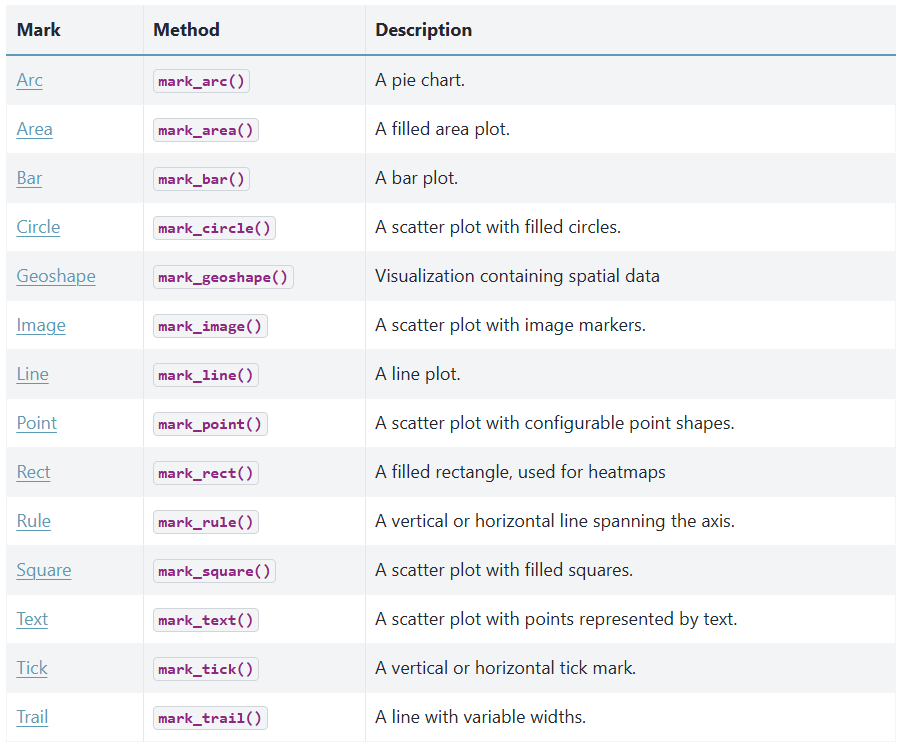


# 3.- Transformación de datos


Hasta ahora hemos visto como representar los datos en una gráfica tal como están, pero muchas veces es recomendable realizar algún tipo de transformación previa sobre ellos antes de mostrarlos en la gráfica. Aunque podemos realizar las transformaciones con Pandas, también es posible hacerlo desde Altair.

Trabajaremos con una tabla de datos sobre **películas**, extraída de la colección `vega-datasets` . Los datos incluyen variables como el título de la película, el director, el género, la fecha de estreno, las calificaciones y la recaudación bruta. 

In [73]:
movies_url = 'https://cdn.jsdelivr.net/npm/vega-datasets@1/data/movies.json'
movies = pd.read_json(movies_url)
movies.head(3)

,Title,US_Gross,Worldwide_Gross,US_DVD_Sales,Production_Budget,Release_Date,MPAA_Rating,Running_Time_min,Distributor,Source,Major_Genre,Creative_Type,Director,Rotten_Tomatoes_Rating,IMDB_Rating,IMDB_Votes
0,The Land Girls,146083.0,146083.0,NaN,8000000.0,Jun 12 1998,R,NaN,Gramercy,None,None,None,None,NaN,6.1,1071.0
1,"First Love, Last Rites",10876.0,10876.0,NaN,300000.0,Aug 07 1998,R,NaN,Strand,None,Drama,None,None,NaN,6.9,207.0
2,I Married a Strange Person,203134.0,203134.0,NaN,250000.0,Aug 28 1998,None,NaN,Lionsgate,None,Comedy,None,None,NaN,6.8,865.0


## 3.1.- Histogramas

Vamos a  comenzar agrupando los datos en **grupos discretos** y contando los registros para resumir esos grupos. Estos gráficos resultantes se conocen como **histogramas**.

Primero mostramos un **diagrama de dispersión** que muestre las calificaciones de películas de *Rotten Tomatoes* frente a las calificaciones de IMDB

In [77]:
( alt.Chart(movies_url)
     .mark_circle()
     .encode(
        alt.X('Rotten_Tomatoes_Rating:Q'),
        alt.Y('IMDB_Rating:Q')
    )
)

alt.Chart(...)

Para agrupar los datos en grupos discretos usaremos el parámetro `bin=True` para 10 *bins* o `bin=alt.BinParams(maxbins=20)` para un número diferente de *bins*, en este ejemplo, 20.

In [79]:
( alt.Chart(movies_url)
     .mark_circle()
     .encode(
        alt.X('Rotten_Tomatoes_Rating:Q', bin=alt.BinParams(maxbins=20)),
        alt.Y('IMDB_Rating:Q')
    )
)

alt.Chart(...)

En el siguiente ejemplo vamos a mostrar en un gráfico de barras únicamente la puntuación en IMDB combinándolo con el número de películas que entran dentro de cada rango, para lo que utilizamos la función agregada `count()`


In [86]:
( alt.Chart(movies_url)
     .mark_bar()
     .encode(
        alt.X('IMDB_Rating:Q', bin=alt.BinParams(maxbins=15)),
        alt.Y('count()')
    )
)

alt.Chart(...)

Volviendo a la marca de puntos, podemos representar diferentes variaciones del gráfico utilizando otros canales.

En el siguiente ejemplo aplicamos la discretización en ambos ejes

In [88]:
( alt.Chart(movies_url)
     .mark_circle()
     .encode(
        alt.X('Rotten_Tomatoes_Rating:Q', bin=alt.BinParams(maxbins=20)),
        alt.Y('IMDB_Rating:Q', bin=alt.BinParams(maxbins=20)),
    )
)

alt.Chart(...)

Aquí se pierde mucha información porque los puntos se dibujan uno encima de otro y no es posible saber a cuántas películas corresponde cada uno. Para cambiar esto, podemos aplicar el canal de codificación de tamaño para que represente el número de películas.

In [89]:
( alt.Chart(movies_url)
     .mark_circle()
     .encode(
        alt.X('Rotten_Tomatoes_Rating:Q', bin=alt.BinParams(maxbins=20)),
        alt.Y('IMDB_Rating:Q', bin=alt.BinParams(maxbins=20)),
        alt.Size('count()')
    )
)

alt.Chart(...)

Alternativamente, podemos codificar los recuentos en el canal de **color** y cambiar el tipo de marca a **bar**. El resultado es un histograma bidimensional en forma de **mapa de calor**

In [90]:
( alt.Chart(movies_url)
     .mark_bar()
     .encode(
        alt.X('Rotten_Tomatoes_Rating:Q', bin=alt.BinParams(maxbins=20)),
        alt.Y('IMDB_Rating:Q', bin=alt.BinParams(maxbins=20)),
        alt.Color('count()')
    )
)

alt.Chart(...)

## 3.2.- Agregación

Los recuentos son solo un tipo de agregación, otras funciones disponibles son `average()`, `median()`, `min()` o `max()`. Veamos algunos ejemplos:

Visualicemos la calificación media en Rotten Tomatoes por género.

In [91]:
( alt.Chart(movies_url)
     .mark_bar()
     .encode(
        alt.X('average(Rotten_Tomatoes_Rating):Q'),
        alt.Y('Major_Genre:N')
    )
)

alt.Chart(...)

Para una imagen más ordenada, ordenamos los géneros en orden descendente de calificación promedio agregando un parámetro `sort` al canal de codificación `y`, indicando que deseamos ordenar por la calificación promedio (`op`) de Rotten Tomatoes (`field`) en orden descedente (`order`)

In [92]:
( alt.Chart(movies_url)
     .mark_bar()
     .encode(
        alt.X('average(Rotten_Tomatoes_Rating):Q'),
        alt.Y('Major_Genre:N',
              sort=alt.EncodingSortField(
                    op='average', field='Rotten_Tomatoes_Rating', order='descending')
             )
    )
)

alt.Chart(...)

# 4.- Escalas, ejes y leyendas

La codificación visual (la asignación de datos a variables visuales como posición, tamaño, forma o color) es la esencia de la visualización de datos. La herramienta fundamental que realiza esta asignación es la escala: una función que toma un valor de datos como entrada (el **dominio** de la escala) y devuelve un valor visual, como la posición de un píxel o un color RGB como salida (el **rango** de la escala).

Además de las marcas gráficas, un gráfico necesita elementos de referencia, o **guías**, que permiten a los elctores interpretar la información. Las guías, como los **ejes** (que visualizan escalas con rangos espaciales) y las **leyendas** (que visualizan escalas con rangos de color, tamaño o forma), son los elementos clave de una visualización de datos eficaz.


## 4.1.- Datos sobre antibióticos

Vamos a usar un conjunto de datos de antibióticos de la colección vega-datasets

In [93]:
url = 'https://cdn.jsdelivr.net/npm/vega-datasets@1/data/burtin.json'
antibiotics = pd.read_json(url)
antibiotics.head(3)

,Bacteria,Penicillin,Streptomycin,Neomycin,Gram_Staining,Genus
0,Aerobacter aerogenes,870.000,1.00,1.600,negative,other
1,Bacillus anthracis,0.001,0.01,0.007,positive,other
2,Brucella abortus,1.000,2.00,0.020,negative,other


# 5.- Composición multivista

Al visualizar varios campos de datos diferentes, podríamos sentir la tentación de usar tantos canales de codificación visual como sea posible. Sin embargo, a medida que aumenta el número de canales de codificación, un gráfico puede volverse rápidamente confuso y difícil de leer. Una alternativa a la sobrecarga de un solo gráfico es componer varios gráficos de manera que faciliten las comparaciones rápidas.

Hay diferentes formas de componer múltiples vistas:

- *Capa*: colocar los gráficos directamente uno encima del otro
- *Facetado*: dividir los datos en múltiples gráficos, organizados en filas columnas.
- *Concatenación*: posicionar gráficos alternativos dentro de un diseño compartido
- *Repetición*: tomar la especificación de un gráfico base y aplicarla a múltiples campos de datos.

## 5.1.- Datos del tiempo

Vamos a utilizar ahora el dataset de estadísticas del clima en las ciudades de Seatle y New York.

In [97]:
weather = 'https://cdn.jsdelivr.net/npm/vega-datasets@1/data/weather.csv'
df = pd.read_csv(weather)
df.head(10)

,location,date,precipitation,temp_max,temp_min,wind,weather
0,Seattle,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,Seattle,2012-01-02,10.9,10.6,2.8,4.5,rain
2,Seattle,2012-01-03,0.8,11.7,7.2,2.3,rain
3,Seattle,2012-01-04,20.3,12.2,5.6,4.7,rain
4,Seattle,2012-01-05,1.3,8.9,2.8,6.1,rain
5,Seattle,2012-01-06,2.5,4.4,2.2,2.2,rain
6,Seattle,2012-01-07,0.0,7.2,2.8,2.3,rain
7,Seattle,2012-01-08,0.0,10.0,2.8,2.0,sun
8,Seattle,2012-01-09,4.3,9.4,5.0,3.4,rain
9,Seattle,2012-01-10,1.0,6.1,0.6,3.4,rain


## 5.2.- Capa

### 5.2.1.- Ejes compartidos

Si los ejes son compatibles podemos superponer las gráficas de los diferentes datos.

In [98]:
( alt.Chart(weather)
     .mark_area()
     .encode(
      alt.X('month(date):T'),
      alt.Y('average(temp_max):Q'),
      alt.Y2('average(temp_min):Q')
    )
)

alt.Chart(...)

El problema del gráfico anterior es que estamos superponiendo las temperaturas de ambas ciudades, por lo que el resultado no nos proporciona mucha información. Se puede mejorar añadiendo la **codificación de color** según la ciudad y establecer transparencia para las áreas que se superponen.

In [99]:
( alt.Chart(weather)
     .mark_area(opacity=0.3)
     .encode(
      alt.X('month(date):T'),
      alt.Y('average(temp_max):Q'),
      alt.Y2('average(temp_min):Q'),
      alt.Color('location:N')
    )
)

alt.Chart(...)

Vamos a agregar ahora una línea para indicar la temperatura media de cada una de las ciudades. Para ello vamos a utilizar `transform_calculate`, que nos permite crear nuevos campos calculados a partir de campos existentes.

Observa lo siguiente:

- Dentro de `transform_calculate` podemos crear los campos que queramos asignándoles un nombre de forma que podremos referenciarlos más adelante
- La cadena `datum` sirve para representar la fila actual en Vega Altair
- El uso del símbolo `+` es un truco que fuerza la conversión de tipos a entero
- En la última línea, al sumar las variables que representan las gráficas estamos indicando que queremos superponerlas. Una alternativa al uso de este operador sería poner la cadena `alt.layer(tempMinMax, tempMid)`

In [102]:
tempMinMax = ( alt.Chart(weather)
                  .mark_area(opacity=0.3)
                  .encode(
                      alt.X('month(date):T'),
                      alt.Y('average(temp_max):Q'),
                      alt.Y2('average(temp_min):Q'),
                      alt.Color('location:N')
                    )
             )

tempMid = ( alt.Chart(weather)
               .mark_line()
               .transform_calculate(
                  temp_mid='(+datum.temp_min + +datum.temp_max) / 2'
                  )
               .encode(
                  alt.X('month(date):T'),
                  alt.Y('average(temp_mid):Q'),
                  alt.Color('location:N')
                )
          )

# alt.layer(tempMinMax, tempMid)
tempMinMax + tempMid

alt.LayerChart(...)

### 5.2.2.- Gráficas con doble eje

Vamos a suponer ahora que queremos comparar los datos de precipitación con los de temperatura en la ciudad de Seatle. En este caso tendríamos que poner en el eje X la fecha, pero en el eje Y debería haber dos rangos diferentes: temperatura y precipitación.

Podemos intentar hacerlo como en el apartado anterior.

In [104]:
tempMinMax = ( alt.Chart(weather)
                  .transform_filter(
                      'datum.location == "Seattle"'
                      )
                  .mark_area( opacity=0.3 )
                  .encode(
                      alt.X('month(date):T', title=None, axis=alt.Axis(format='%b')),
                      alt.Y('average(temp_max):Q', title='Avg. Temperature °C'),
                      alt.Y2('average(temp_min):Q')
                    )
             )

precip = ( alt.Chart(weather)
              .transform_filter(
                  'datum.location == "Seattle"'
                  )
              .mark_line(
                  interpolate='monotone',
                  stroke='grey'
                  )
              .encode(
                  alt.X('month(date):T'),
                  alt.Y('average(precipitation):Q', title='Precipitation')
                )
         )

alt.layer(tempMinMax, precip)

alt.LayerChart(...)

Por defecto, Altair considera que es un dominio compartido, es decir, que tienen las mismas unidades. La consecuencia de esto es que las temperaturas se mostrarán en un rango mucho más pequeño que las precipitaciones

In [105]:
tempMinMax = alt.Chart(weather).transform_filter(
  'datum.location == "Seattle"'
).mark_area(opacity=0.3).encode(
  alt.X('month(date):T', title=None, axis=alt.Axis(format='%b')),
  alt.Y('average(temp_max):Q', title='Avg. Temperature °C'),
  alt.Y2('average(temp_min):Q')
)

precip = alt.Chart(weather).transform_filter(
  'datum.location == "Seattle"'
).mark_line(
  interpolate='monotone',
  stroke='grey'
).encode(
  alt.X('month(date):T'),
  alt.Y('average(precipitation):Q', title='Precipitation')
)

alt.layer(tempMinMax, precip).resolve_scale(y='independent')

alt.LayerChart(...)